# 3D-графика

Для 3D-графики в matplotlib используется пакет mpl_toolkits.mplot3.

## Способ 1

Для того чтобы создать 3D-график, нужно создать экземпляр класса mpl_toolkits.mplot3d.Axes3D.

In [1]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt

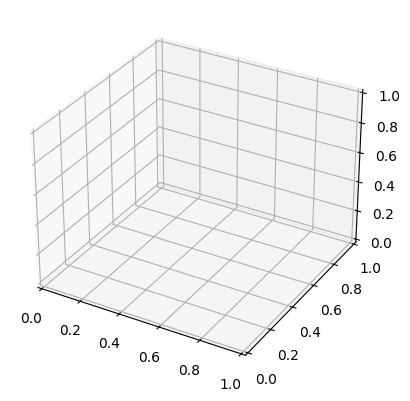

In [2]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plt.show()

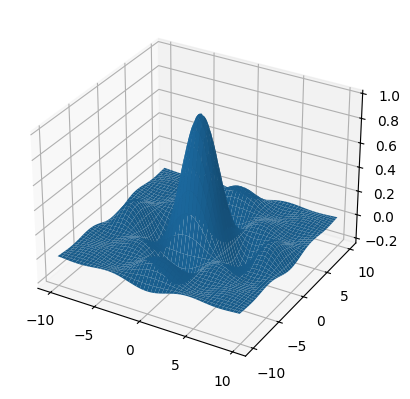

In [3]:
x = np.arange (-10, 10, 0.1)
y = np.arange (-10, 10, 0.1)

xgrid, ygrid = np.meshgrid(x, y)
zgrid = np.sin (xgrid) * np.sin (ygrid) / (xgrid * ygrid)

fig = plt.figure()
axes = fig.add_subplot(111, projection='3d')

axes.plot_surface(xgrid, ygrid, zgrid)

plt.show()

## Способ 2

3D-оси могут быть добавлены на холст фигуры Matplotlib точно так же, как 2D-оси.

Или, что более удобно, путем передачи ключевого аргумента **projection='3d'** в методы **add_axes** или **add_subplot**.

### Линейный график

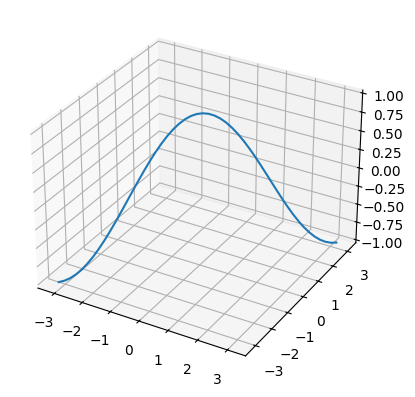

In [4]:
x = np.linspace(-np.pi, np.pi, 50)
y = x
z = np.cos(x)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, label='parametric curve')

### Точечный график scatter()

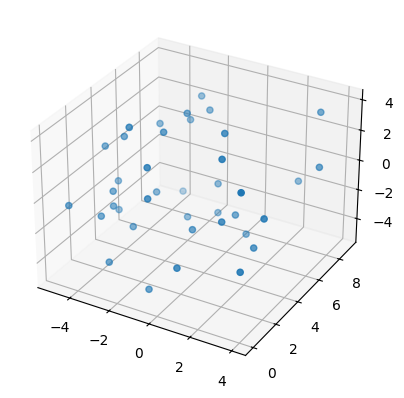

In [5]:
np.random.seed(123)
x = np.random.randint(-5, 5, 40)
y = np.random.randint(0, 10, 40)
z = np.random.randint(-5, 5, 40)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z)

### Поверхности plot_surface()

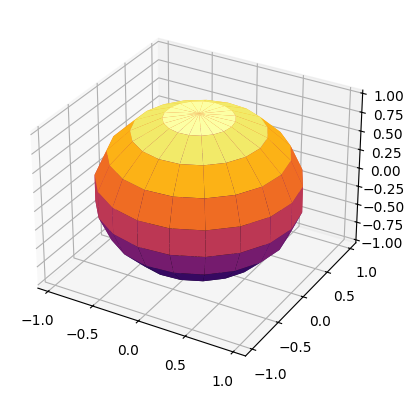

In [6]:
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x, y, z, cmap='inferno')

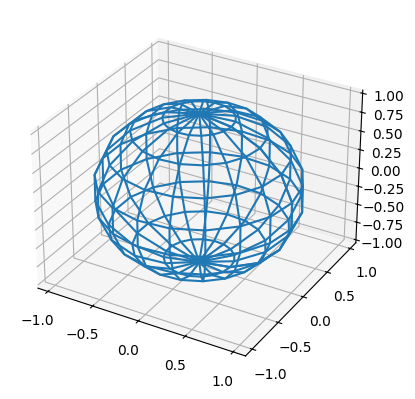

In [7]:
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(x, y, z)

### Контурные участки с проекциями

In [8]:
alpha = 0.7
phi_ext = 2 * np.pi * 0.5

def flux_qubit_potential(phi_m, phi_p):
    return 2 + alpha - 2 * np.cos(phi_p) * np.cos(phi_m) - alpha * np.cos(phi_ext - 2*phi_p)

phi_m = np.linspace(0, 2*np.pi, 100)
phi_p = np.linspace(0, 2*np.pi, 100)
X,Y = np.meshgrid(phi_p, phi_m)
Z = flux_qubit_potential(X, Y).T

(-3.141592653589793, 6.283185307179586)

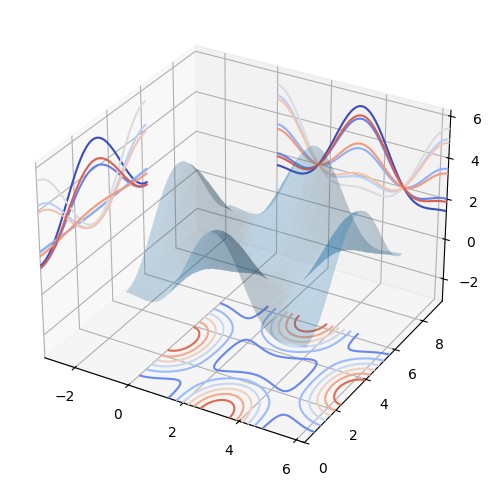

In [9]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(1,1,1, projection='3d')

ax.plot_surface(X, Y, Z, rstride=4, cstride=4, alpha=0.25)
cset = ax.contour(X, Y, Z, zdir='z', offset=-np.pi, cmap=mpl.cm.coolwarm)
cset = ax.contour(X, Y, Z, zdir='x', offset=-np.pi, cmap=mpl.cm.coolwarm)
cset = ax.contour(X, Y, Z, zdir='y', offset=3*np.pi, cmap=mpl.cm.coolwarm)

ax.set_xlim3d(-np.pi, 2*np.pi)
ax.set_ylim3d(0, 3*np.pi)
ax.set_zlim3d(-np.pi, 2*np.pi)

### Изменение угла обзора

Можно изменить перспективу трехмерного графика, используя метод view_init, который принимает два аргумента: угол места и угол азимута (в градусах):

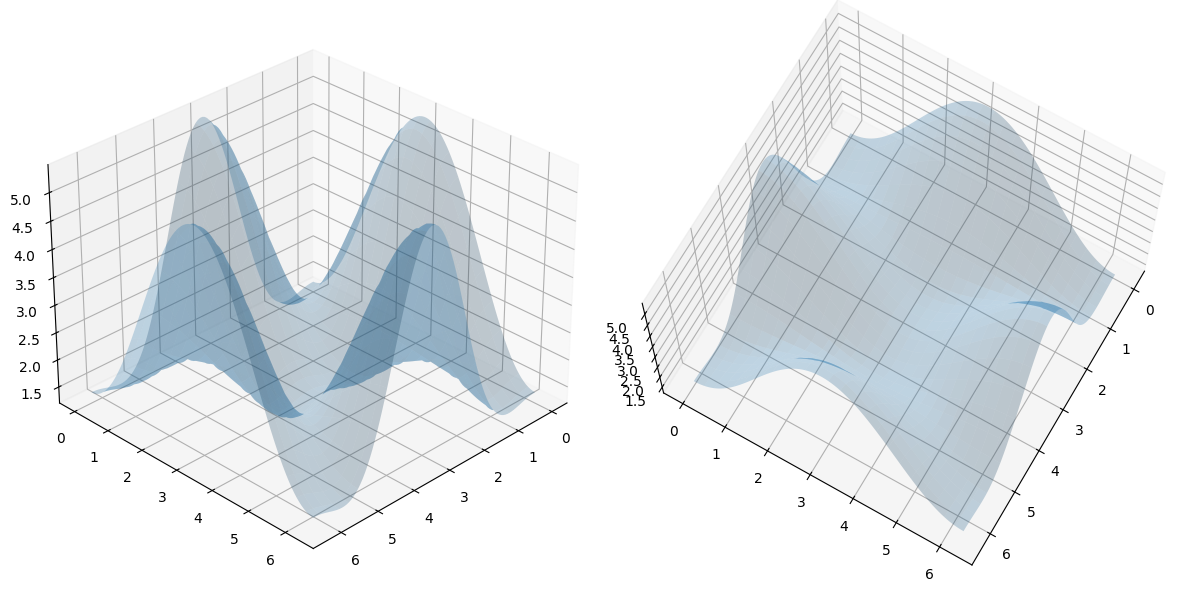

In [10]:
fig = plt.figure(figsize=(12,6))

ax = fig.add_subplot(1,2,1, projection='3d')
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, alpha=0.25)
ax.view_init(30, 45)

ax = fig.add_subplot(1,2,2, projection='3d')
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, alpha=0.25)
ax.view_init(70, 30)

fig.tight_layout()


### [Календарные данные](https://matplotlib.org/3.1.0/api/dates_api.html)

Иногда нужно построить график, на котором по оси **X** отложены не числа, а календарные значения (даты или время). Библиотека **Matplotlib** позволяет рисовать и такие графики.

Если списки данных, которые нужно отложить по осям **X** и **Y**, уже сформированы (в качестве календарного типа используется класс date или datetime), то для того, чтобы по оси были отображены даты, нужно выполнить следующие шаги:

1. Преобразовать даты в числовой формат, понятный для Matplotlib.
   Это делается с помощью функции **matplotlib.dates.date2num**.

2. Установить для оси форматтер, специально предназначенный для отображения дат и времени.

3. При необходимости установить локатор, предназначенный для работы с календарными данными.

4. Построить график с помощью `plot_date`, передав числовые данные, полученные на первом шаге.

/tmp/ipykernel_10922/1671149474.py:24: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date (xdata_float, ydata, fmt="b-")


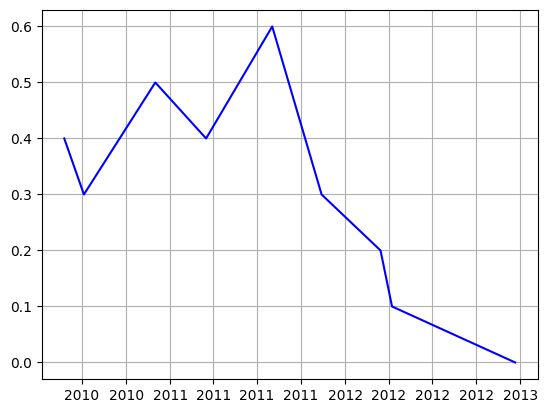

In [11]:
from datetime import date
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates

xdata = [date (2010, 5, 25),
         date (2010, 7, 5),
         date (2010, 12, 1),
         date (2011, 3, 17),
         date (2011, 8, 2),
         date (2011, 11, 13),
         date (2012, 3, 15),
         date (2012, 4, 8),
         date (2012, 12, 21)
         ]

ydata = [0.4, 0.3, 0.5, 0.4, 0.6, 0.3, 0.2, 0.1, 0.0]
xdata_float = mpl.dates.date2num (xdata)

axes = plt.subplot(1, 1, 1)

axes.xaxis.set_major_formatter (mpl.dates.DateFormatter("%Y"))

plt.plot_date (xdata_float, ydata, fmt="b-")

plt.grid()
plt.show()

In [12]:
import statsmodels.api as sm
import pandas as pd

df = sm.datasets.co2.load_pandas().data
df = df.dropna()  # удаляем пропуски
df['date'] = pd.to_datetime(df.index)
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df.head()

,co2,date,Year,Month
1958-03-29,316.1,1958-03-29,1958,3
1958-04-05,317.3,1958-04-05,1958,4
1958-04-12,317.6,1958-04-12,1958,4
1958-04-19,317.5,1958-04-19,1958,4
1958-04-26,316.4,1958-04-26,1958,4


In [13]:
import numpy as np

years = df['Year'].unique()
months = np.arange(1,13)

Yg, Mg = np.meshgrid(years, months)

Zg = np.zeros_like(Yg, dtype=float)
for i, y in enumerate(years):
    for j, m in enumerate(months):
        vals = df[(df['Year']==y) & (df['Month']==m)]['co2']
        Zg[j, i] = vals.mean() if len(vals)>0 else np.nan

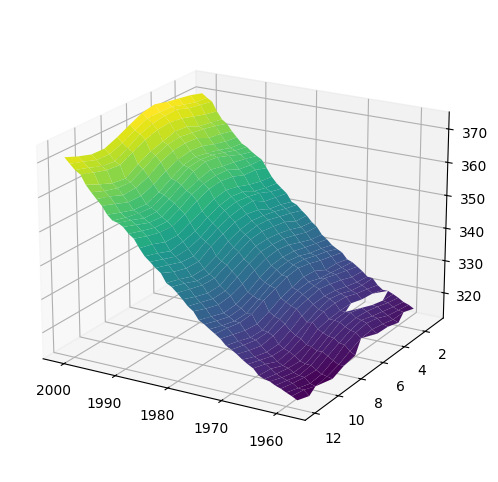

In [14]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Yg, Mg, Zg, cmap='viridis')
ax.view_init(20, 120)
plt.show()

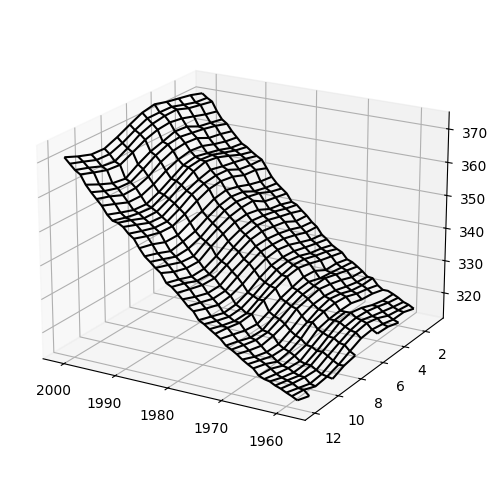

In [15]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(Yg, Mg, Zg, color='black')
ax.view_init(20, 120)
plt.show()

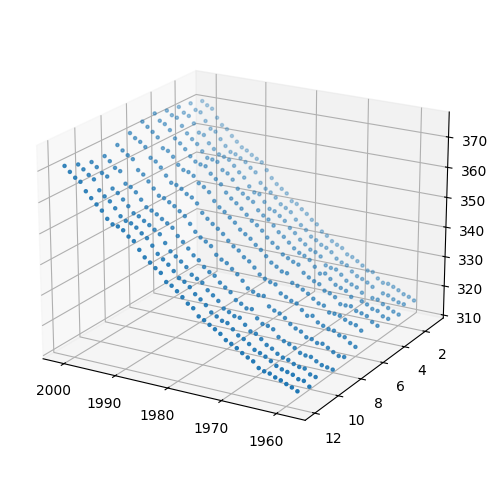

In [16]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Yg, Mg, Zg, s=5)
ax.view_init(20, 120)
plt.show()